<a href="https://colab.research.google.com/github/Egyy24/Prediksi-diabetes-menggunakan-logistic-regression/blob/main/Diabetics_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anggota Kelompok:


> Qanzul Arays (23523228)


> Muhammad Ibnu Rasyid (23523127)










# Dataset dan Target Klasifikasi

Dataset: [Diabetics prediction using logistic regression](https://www.kaggle.com/datasets/kandij/diabetes-dataset)


---



Dataset yang digunakan adalah Pima Indians Diabetes
Dataset, yang berisi data medis dari 768 pasien wanita keturunan suku Pima Indian. Dataset ini memiliki 8 fitur input berupa informasi kesehatan yaitu pregnancies, glucose, bloodpressure, skinthickness, insulin, BMI, diabetes pedigree function, dan age.

Target klasifikasi pada dataset ini adalah kolom Outcome, yang dipisahkan dari dataset menggunakan perintah `y = df['Outcome']`. Kolom ini memiliki dua kelas diskrit bernilai 0 jika pasien tidak menderita diabetes, dan 1 jika pasien menderita diabetes. Dari total 768 data, terdapat 500 pasien berlabel 0 (tidak diabetes) dan 268 pasien berlabel 1 (diabetes).

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/diabetes2.csv')

display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
display(df['Outcome'].value_counts())
display(df['Outcome'].value_counts(normalize=True) * 100)

,count
Outcome,
0,500
1,268


,proportion
Outcome,
0,65.104167
1,34.895833


# Preprocessing Data yang Diperlukan

In [ ]:
display(df.isnull().sum())

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Dataset terlihat bersih tanpa data kosong yang jelas. Tapi, nilai 0 pada kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI bisa jadi sebenarnya data yang hilang,

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


# Pembagian Data Training dan Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


# Membangun Model Logistic Regression
Akurasi model mencapai akurasi sekitar 71.43%, yang berarti 71.43% dari total prediksi adalah benar.

**Kelas 0 (Tidak diabetes)**
*  Precision (0.76) dari semua kasus yang diprediksi tidak diabetes, 76% di antaranya benar-benar tidak diabetes.
*   Recall (0.82) dari semua kasus yang sebenarnya tidak diabetes, model berhasil mengidentifikasi 82% di antaranya.
*   F1-score (0.79) merupakan rata-rata harmonik dari precision dan recall, menunjukkan keseimbangan kinerja yang baik untuk kelas ini.


**Kelas 1 (Diabetes)**
*  Precision (0.61) dari semua kasus yang diprediksi diabetes, hanya 61% di antaranya yang benar-benar diabetes.
*   Recall (0.52) dari semua kasus yang sebenarnya diabetes, model hanya berhasil mengidentifikasi 52% di antaranya.
*   F1-score (0.56) menunjukkan bahwa model memiliki kesulitan yang lebih besar dalam memprediksi kelas diabetes dibandingkan dengan kelas tidak diabetes.

Makna True Positive, False Positive, True Negative, dan False Negative:


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Accuracy: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,82,18
Actual 1,26,28


*   True Positive (TP): Kasus di mana model dengan benar memprediksi seseorang memiliki diabetes (Aktual: 1, Prediksi: 1). Berdasarkan Confusion Matrix, ada 28 TP.
*   False Positive (FP): Kasus di mana model secara keliru memprediksi seseorang memiliki diabetes, padahal sebenarnya tidak (Aktual: 0, Prediksi: 1). Berdasarkan Confusion Matrix, ada 18 FP.
*   True Negative (TN): Kasus di mana model dengan benar memprediksi seseorang tidak memiliki diabetes (Aktual: 0, Prediksi: 0). Berdasarkan Confusion Matrix, ada 82 TN.
*   False Negative (FN): Kasus di mana model secara keliru memprediksi seseorang tidak memiliki diabetes, padahal sebenarnya memiliki (Aktual: 1, Prediksi: 0). Berdasarkan Confusion Matrix, ada 26 FN.

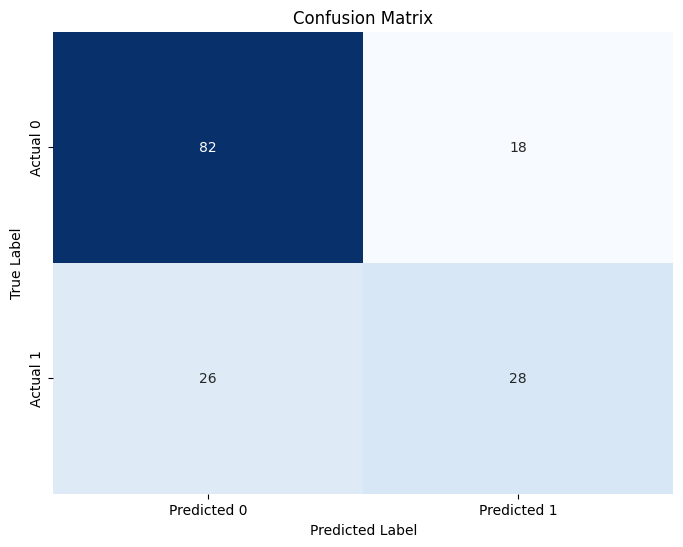

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

print("Contoh Perbandingan Label Aktual dan Prediksi:")
display(comparison_df.head(20))

Contoh Perbandingan Label Aktual dan Prediksi:


,Actual,Predicted
44,0,1
672,0,0
700,0,0
630,1,0
81,0,0
389,0,0
387,1,0
408,1,1
163,0,0
335,0,1


# Kesimpulan
Model Logistic Regression menunjukkan kinerja yang cukup baik dalam mengklasifikasikan individu yang tidak memiliki diabetes (Kelas 0), dengan recall yang tinggi (82%). Tapi, model ini kurang efektif dalam mengidentifikasi individu yang sebenarnya menderita diabetes (Kelas 1), terbukti dari recall yang rendah (52%) dan precision yang moderat (61%). Ini berarti model cenderung menghasilkan lebih banyak False Negatives (individu dengan diabetes yang tidak terdeteksi) dan False Positives (individu sehat yang diprediksi diabetes). Untuk studi kasus deteksi diabetes, False Negatives seringkali lebih berbahaya, karena mengabaikan kondisi serius.